<a href="https://colab.research.google.com/github/SebastiaoFigueredo/introducao_ia_projeto/blob/main/C%C3%B3pia_de_Diagnostico_doencas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
# Importa a biblioteca pandas para manipulação de dados
import pandas as pd

In [31]:
# Carrega os dados do arquivo CSV 'dados.csv' em um DataFrame do pandas
df = pd.read_csv('dados.csv')

In [53]:
import os

# Lista todos os arquivos no diretório atual (onde o Colab geralmente coloca os arquivos carregados)
files_in_current_directory = os.listdir('.')
print(f"Arquivos no diretório atual: {files_in_current_directory}")

# Verifica se 'dados.csv' está na lista
if 'dados.csv' in files_in_current_directory:
    print("O arquivo 'dados.csv' foi carregado com sucesso!")
else:
    print("O arquivo 'dados.csv' NÃO foi encontrado no diretório atual.")

Arquivos no diretório atual: ['.config', 'dados.csv', 'sample_data']
O arquivo 'dados.csv' foi carregado com sucesso!


In [32]:
# Verifica o tipo do objeto 'df' para confirmar que é um DataFrame do pandas
type(df)

pandas.core.frame.DataFrame

In [33]:
# Exibe as primeiras 5 linhas do DataFrame para uma visualização rápida dos dados
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [34]:
# Exibe informações resumidas sobre o DataFrame, incluindo tipos de dados, contagem de valores não nulos e uso de memória
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


<Axes: ylabel='Frequency'>

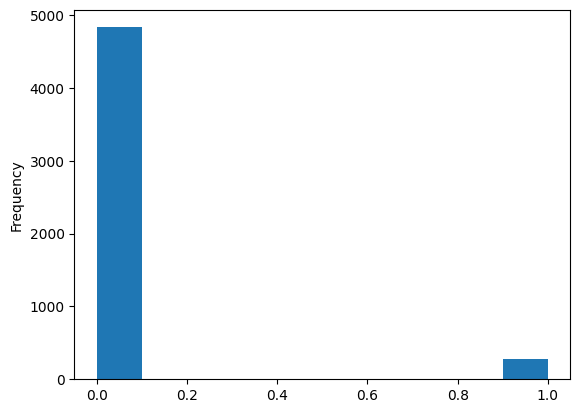

In [35]:
# Importa a função histogram do numpy (embora não seja diretamente usada aqui, 'plot(kind=hist)' do pandas a utiliza internamente)
from numpy import histogram
# Plota um histograma da coluna 'heart_disease' para visualizar sua distribuição
df['heart_disease'].plot(kind='hist')

In [36]:
# Gera estatísticas descritivas para a coluna 'heart_disease' e as converte para o tipo string
df.heart_disease.describe().astype(str)

,heart_disease
count,5110.0
mean,0.05401174168297456
std,0.22606298750336476
min,0.0
25%,0.0
50%,0.0
75%,0.0
max,1.0


<Axes: ylabel='Frequency'>

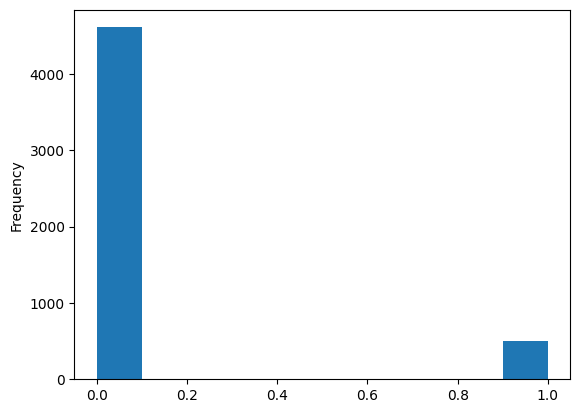

In [37]:
# Plota um histograma da coluna 'hypertension' para visualizar sua distribuição
df['hypertension'].plot(kind='hist')

In [4]:
# Este código geraria estatísticas descritivas para a coluna 'hypertension' e as converteria para string, mas está comentado.
# df.hypertension.describe().astype(str)

<Axes: >

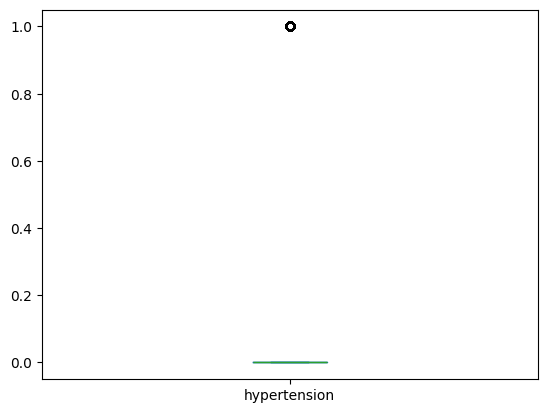

In [38]:
# Plota um boxplot da coluna 'hypertension' para identificar a mediana, quartis e possíveis outliers
df.hypertension.plot(kind='box')

outliers


In [39]:
# Exibe as primeiras 5 linhas do DataFrame novamente
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


<Axes: xlabel='age', ylabel='heart_disease'>

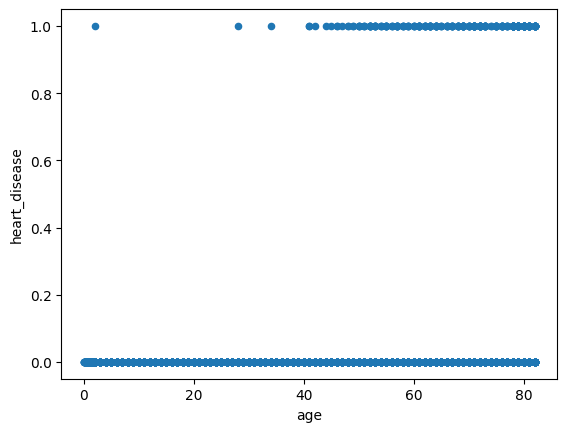

In [40]:
# Plota um gráfico de dispersão ('scatter plot') entre 'age' e 'heart_disease' para visualizar a relação entre as duas variáveis
df.plot(kind='scatter', x='age', y='heart_disease')

In [16]:
# Importa a biblioteca seaborn para visualização de dados mais avançada
import seaborn as sns

In [41]:
# Calcula a matriz de correlação entre todas as variáveis numéricas do DataFrame
correlacao = df.corr(numeric_only=True)

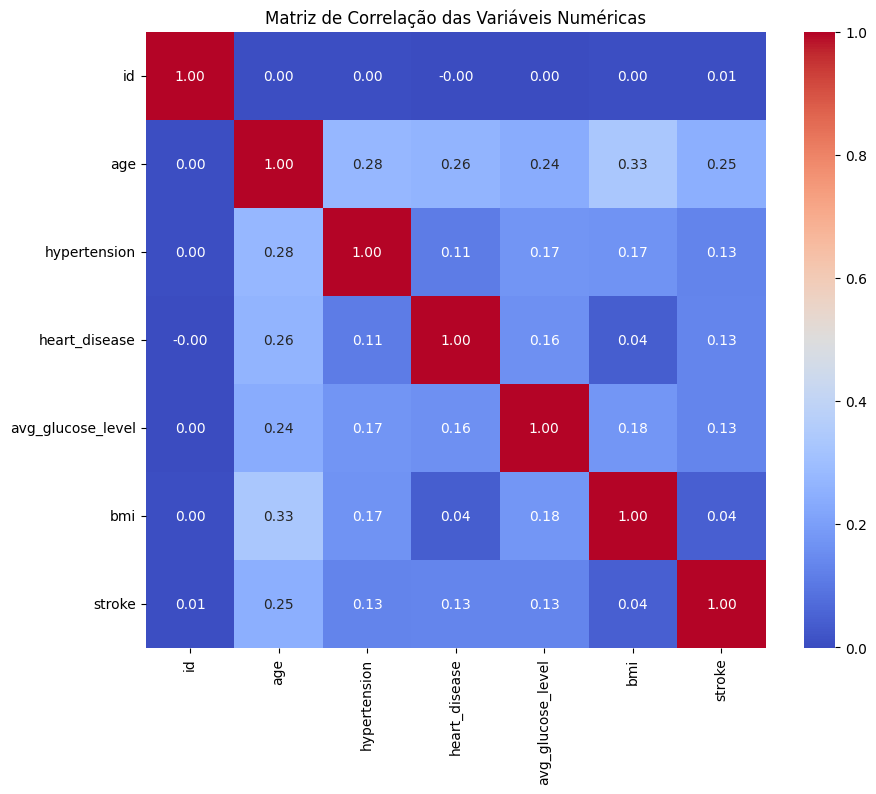

In [42]:
# Importa a biblioteca matplotlib.pyplot para plotagem de gráficos
import matplotlib.pyplot as plt

# Define o tamanho da figura para o heatmap
plt.figure(figsize=(10, 8))
# Cria um heatmap da matriz de correlação, exibindo os valores com duas casas decimais e usando o mapa de cores 'coolwarm'
sns.heatmap(correlacao, annot=True, cmap='coolwarm', fmt=".2f")
# Adiciona um título ao gráfico
plt.title('Matriz de Correlação das Variáveis Numéricas')
# Exibe o gráfico
plt.show()

In [43]:
# Separa as features (X) do DataFrame, removendo a coluna 'heart_disease'
X = df.drop(columns=['heart_disease'])
# Define a variável alvo (y) como a coluna 'heart_disease'
y = df.heart_disease

In [44]:
# Exibe o DataFrame de features (variáveis independentes)
X

,id,gender,age,hypertension,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


In [45]:
# Exibe a série da variável alvo (variável dependente)
y

,heart_disease
0,1
1,0
2,1
3,0
4,0
...,...
5105,0
5106,0
5107,0
5108,0


In [46]:
# Importa a função train_test_split para dividir os dados em conjuntos de treino e teste
from sklearn.model_selection import train_test_split

# Divide X e y em conjuntos de treino e teste, com 20% dos dados para teste e um estado aleatório fixo para reprodutibilidade
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [47]:
# Exibe o conjunto de dados de treino das features
X_train

,id,gender,age,hypertension,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
802,4970,Male,79.00,0,Yes,Self-employed,Rural,112.64,28.5,formerly smoked,0
3927,56137,Female,62.00,0,Yes,Private,Urban,88.32,36.3,Unknown,0
2337,54590,Female,21.00,0,No,Private,Rural,59.52,33.7,never smoked,0
3910,36548,Male,31.00,0,Yes,Govt_job,Urban,65.70,30.4,formerly smoked,0
1886,61171,Female,31.00,0,No,Private,Rural,59.63,19.9,never smoked,0
...,...,...,...,...,...,...,...,...,...,...,...
4426,13846,Male,43.00,0,Yes,Govt_job,Rural,88.00,30.6,never smoked,0
466,1307,Female,61.00,1,Yes,Private,Rural,170.05,60.2,smokes,0
3092,31481,Female,1.16,0,No,children,Urban,97.28,17.8,Unknown,0
3772,61827,Male,80.00,0,Yes,Self-employed,Rural,196.08,31.0,formerly smoked,0


In [48]:
# Importa as bibliotecas necessárias para o modelo de Regressão Logística, avaliação e tratamento de valores ausentes
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd
from sklearn.impute import SimpleImputer

# Aplica one-hot encoding nas features categóricas dos conjuntos de treino e teste
# 'drop_first=True' evita a multicolinearidade
X_train_encoded = pd.get_dummies(X_train, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, drop_first=True)

# Alinha as colunas de X_test_encoded para corresponder às de X_train_encoded
# Isso garante que ambos os conjuntos tenham as mesmas colunas, preenchendo com 0 onde não houver correspondência
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

# Imputa valores ausentes (por exemplo, na coluna 'bmi') usando a estratégia de média
imputer = SimpleImputer(strategy='mean')
# Aplica o imputer para preencher os valores ausentes no conjunto de treino
X_train_encoded_imputed = pd.DataFrame(imputer.fit_transform(X_train_encoded), columns=X_train_encoded.columns, index=X_train_encoded.index)
# Aplica o imputer (já ajustado ao treino) para preencher os valores ausentes no conjunto de teste
X_test_encoded_imputed = pd.DataFrame(imputer.transform(X_test_encoded), columns=X_test_encoded.columns, index=X_test_encoded.index)

# Inicializa o modelo de Regressão Logística, aumentando 'max_iter' para garantir a convergência
model_1 = LogisticRegression(max_iter=1000)
# Treina o modelo com os dados de treino imputados e codificados
model_1.fit(X_train_encoded_imputed, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [49]:
# Importa o modelo de Regressão Logística
from sklearn.linear_model import LogisticRegression

# Inicializa o modelo de Regressão Logística, aumentando 'max_iter' para garantir a convergência
# Este bloco parece ser uma re-execução ou refatoração do ajuste do modelo
model_1 = LogisticRegression(max_iter=1000)
# Treina o modelo com os dados de treino imputados e codificados
model_1.fit(X_train_encoded_imputed, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [50]:
# Avalia a acurácia do modelo no conjunto de treino
model_1.score(X_train_encoded_imputed, y_train)

0.9471624266144814

In [51]:
# Exibe o termo de intercepto (constante) do modelo de Regressão Logística
model_1.intercept_

array([-6.93979638])

In [52]:
# Exibe os coeficientes (pesos) de cada feature no modelo de Regressão Logística
model_1.coef_

array([[-2.39572710e-06,  7.70077534e-02,  1.14410809e-01,
         5.35363960e-03, -1.43753472e-02,  3.59212870e-01,
         8.38713749e-01, -5.32533885e-01, -1.15034558e-01,
        -1.52671237e-01, -4.68576880e-01, -2.36658768e+00,
        -1.26537505e-01, -1.41975396e-01, -5.89370192e-01,
         1.30482796e-01]])

In [54]:
# Faz previsões no conjunto de teste
y_pred = model_1.predict(X_test_encoded_imputed)

# Calcula a matriz de confusão
conf_matrix = confusion_matrix(y_test, y_pred)
print("Matriz de Confusão:")
print(conf_matrix)

Matriz de Confusão:
[[959   3]
 [ 59   1]]


In [55]:
# Calcula e imprime o relatório de classificação, que inclui precisão, recall e F1-score
print("Relatório de Classificação:")
print(classification_report(y_test, y_pred))

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       962
           1       0.25      0.02      0.03        60

    accuracy                           0.94      1022
   macro avg       0.60      0.51      0.50      1022
weighted avg       0.90      0.94      0.91      1022



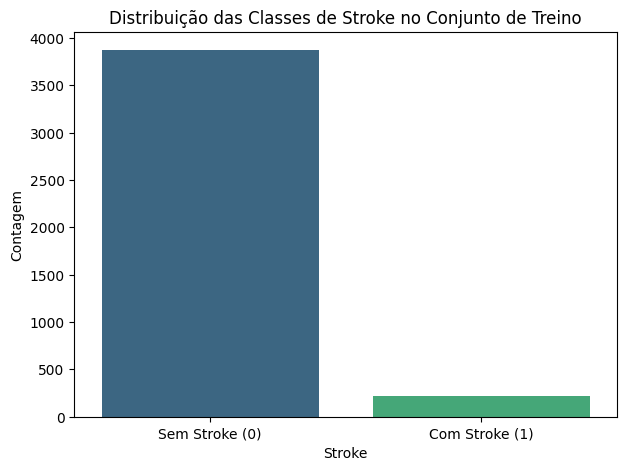

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns # Certifique-se de que seaborn está importado

# Conta a ocorrência de cada classe em y_train
class_distribution = y_train.value_counts()

# Cria o gráfico de barras
plt.figure(figsize=(7, 5))
sns.barplot(x=class_distribution.index, y=class_distribution.values, hue=class_distribution.index, palette='viridis', legend=False)
plt.title('Distribuição das Classes de Stroke no Conjunto de Treino')
plt.xlabel('Stroke')
plt.ylabel('Contagem')
plt.xticks(ticks=[0, 1], labels=['Sem Stroke (0)', 'Com Stroke (1)'])
plt.show()

### Tratamento do Desequilíbrio de Classes com SMOTE

Como notamos um desequilíbrio significativo entre as classes, vamos aplicar o SMOTE (Synthetic Minority Over-sampling Technique) para criar amostras sintéticas da classe minoritária (`heart_disease=1`) e tentar balancear o conjunto de treino. Isso geralmente melhora o desempenho do modelo na classe minoritária.

In [58]:
# Instala a biblioteca imbalanced-learn se ainda não estiver instalada
# !pip install imbalanced-learn

from imblearn.over_sampling import SMOTE
from collections import Counter

print(f"Distribuição da classe antes do SMOTE: {Counter(y_train)}")

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_encoded_imputed, y_train)

print(f"Distribuição da classe após o SMOTE: {Counter(y_train_res)}")

Distribuição da classe antes do SMOTE: Counter({0: 3872, 1: 216})
Distribuição da classe após o SMOTE: Counter({0: 3872, 1: 3872})


Agora que o conjunto de treino está balanceado, podemos treinar um novo modelo e avaliar seu desempenho para ver se houve melhora na previsão da classe minoritária.

In [61]:
# Importa o scaler para normalização dos dados
from sklearn.preprocessing import StandardScaler

# Inicializa o StandardScaler
scaler = StandardScaler()

# Ajusta o scaler aos dados de treino rebalanceados e os transforma
X_train_res_scaled = scaler.fit_transform(X_train_res)
# Transforma os dados de teste usando o scaler já ajustado
X_test_scaled = scaler.transform(X_test_encoded_imputed)

# Inicializa um novo modelo de Regressão Logística para o conjunto de dados rebalanceado e escalado
# Aumentando 'max_iter' para garantir a convergência
model_2 = LogisticRegression(max_iter=5000) # Mantido em 5000

# Treina o modelo com os dados de treino rebalanceados e escalados pelo SMOTE
model_2.fit(X_train_res_scaled, y_train_res)

print("Novo modelo treinado com dados balanceados e escalados (model_2).")

Novo modelo treinado com dados balanceados e escalados (model_2).


### Modelo de Random Forest

In [66]:
# Importa o modelo Random Forest
from sklearn.ensemble import RandomForestClassifier

# Inicializa o modelo Random Forest
# Podemos ajustar os parâmetros como n_estimators, max_depth, etc. para otimização
model_rf = RandomForestClassifier(random_state=42)

# Treina o modelo com os dados de treino rebalanceados e escalados
model_rf.fit(X_train_res_scaled, y_train_res)

print("Modelo Random Forest treinado com dados balanceados e escalados.")

Modelo Random Forest treinado com dados balanceados e escalados.


In [67]:
# Faz previsões no conjunto de teste escalado usando o model_rf
y_pred_rf = model_rf.predict(X_test_scaled)

# Calcula a matriz de confusão para o model_rf
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)
print("Matriz de Confusão para o modelo Random Forest:")
print(conf_matrix_rf)

Matriz de Confusão para o modelo Random Forest:
[[950  12]
 [ 57   3]]


In [68]:
# Calcula e imprime o relatório de classificação para o model_rf
print("Relatório de Classificação para o modelo Random Forest:")
print(classification_report(y_test, y_pred_rf))

Relatório de Classificação para o modelo Random Forest:
              precision    recall  f1-score   support

           0       0.94      0.99      0.96       962
           1       0.20      0.05      0.08        60

    accuracy                           0.93      1022
   macro avg       0.57      0.52      0.52      1022
weighted avg       0.90      0.93      0.91      1022



### Otimização de Hiperparâmetros do Random Forest com GridSearchCV

In [89]:
from sklearn.model_selection import GridSearchCV

# Definir o grid de parâmetros a serem testados
param_grid = {
    'n_estimators': [100, 200, 300], # Número de árvores na floresta
    'max_depth': [10, 20, 30, None],  # Profundidade máxima da árvore
    'min_samples_split': [2, 5, 10], # Número mínimo de amostras necessárias para dividir um nó interno
    'min_samples_leaf': [1, 2, 4]    # Número mínimo de amostras necessárias em um nó folha
}

# Inicializar o modelo Random Forest
rf_model_grid = RandomForestClassifier(random_state=42)

# Configurar o GridSearchCV
# Alterado 'scoring' para 'roc_auc' para otimizar a área sob a curva ROC
grid_search_roc_auc = GridSearchCV(estimator=rf_model_grid, param_grid=param_grid,
                           cv=3, n_jobs=-1, verbose=2, scoring='roc_auc')

# Ajustar o GridSearchCV aos dados de treino rebalanceados e escalados
print("Iniciando GridSearchCV para Random Forest (foco no AUC-ROC)...")
grid_search_roc_auc.fit(X_train_res_scaled_reduced, y_train_res_final)
print("GridSearchCV concluído.")

Iniciando GridSearchCV para Random Forest (foco no AUC-ROC)...
Fitting 3 folds for each of 108 candidates, totalling 324 fits
GridSearchCV concluído.


In [90]:
# Exibir os melhores parâmetros encontrados
print("Melhores parâmetros encontrados (otimizado para AUC-ROC):")
print(grid_search_roc_auc.best_params_)

# Exibir a melhor pontuação (AUC-ROC) encontrada
print("Melhor AUC-ROC (treino balanceado):") # Texto atualizado
print(grid_search_roc_auc.best_score_)

Melhores parâmetros encontrados (otimizado para AUC-ROC):
{'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Melhor AUC-ROC (treino balanceado):
0.996048724370881


### Avaliação do Novo Modelo Random Forest (Otimizado para AUC-ROC)

In [91]:
# Obter o melhor modelo do GridSearchCV otimizado para AUC-ROC
best_rf_model_roc_auc = grid_search_roc_auc.best_estimator_

# Fazer previsões no conjunto de teste com o melhor modelo
y_pred_best_rf_roc_auc = best_rf_model_roc_auc.predict(X_test_scaled_reduced)

# Avaliar o desempenho do melhor modelo no conjunto de teste
print("\nRelatório de Classificação do Melhor Modelo Random Forest (no conjunto de teste, otimizado para AUC-ROC):")
print(classification_report(y_test_final, y_pred_best_rf_roc_auc))

print("Matriz de Confusão do Melhor Modelo Random Forest (no conjunto de teste, otimizado para AUC-ROC):")
print(confusion_matrix(y_test_final, y_pred_best_rf_roc_auc))

# Calcular e imprimir o AUC
y_pred_proba_best_rf_roc_auc = best_rf_model_roc_auc.predict_proba(X_test_scaled_reduced)[:, 1]
fpr_best_rf_roc_auc, tpr_best_rf_roc_auc, _ = roc_curve(y_test_final, y_pred_proba_best_rf_roc_auc)
roc_auc_best_rf_roc_auc = auc(fpr_best_rf_roc_auc, tpr_best_rf_roc_auc)
print(f"\nAUC para Best Random Forest Model (otimizado para AUC-ROC): {roc_auc_best_rf_roc_auc:.2f}")


Relatório de Classificação do Melhor Modelo Random Forest (no conjunto de teste, otimizado para AUC-ROC):
              precision    recall  f1-score   support

           0       0.93      0.99      0.96       952
           1       0.25      0.04      0.07        70

    accuracy                           0.93      1022
   macro avg       0.59      0.52      0.52      1022
weighted avg       0.89      0.93      0.90      1022

Matriz de Confusão do Melhor Modelo Random Forest (no conjunto de teste, otimizado para AUC-ROC):
[[943   9]
 [ 67   3]]

AUC para Best Random Forest Model (otimizado para AUC-ROC): 0.83


In [74]:
# Obter o melhor modelo do GridSearchCV
best_rf_model = grid_search.best_estimator_

# Fazer previsões no conjunto de teste com o melhor modelo
y_pred_best_rf = best_rf_model.predict(X_test_scaled)

# Avaliar o desempenho do melhor modelo no conjunto de teste
print("\nRelatório de Classificação do Melhor Modelo Random Forest (no conjunto de teste, otimizado para Recall):")
print(classification_report(y_test, y_pred_best_rf))

print("Matriz de Confusão do Melhor Modelo Random Forest (no conjunto de teste, otimizado para Recall):")
print(confusion_matrix(y_test, y_pred_best_rf))


Relatório de Classificação do Melhor Modelo Random Forest (no conjunto de teste, otimizado para Recall):
              precision    recall  f1-score   support

           0       0.94      0.98      0.96       962
           1       0.17      0.07      0.10        60

    accuracy                           0.93      1022
   macro avg       0.56      0.52      0.53      1022
weighted avg       0.90      0.93      0.91      1022

Matriz de Confusão do Melhor Modelo Random Forest (no conjunto de teste, otimizado para Recall):
[[942  20]
 [ 56   4]]


### Análise de Importância das Características (Feature Importance) do Random Forest

Agora, vamos identificar quais características o modelo Random Forest considerou mais importantes para fazer suas previsões. Isso pode oferecer insights valiosos sobre os fatores que mais influenciam a doença cardíaca.

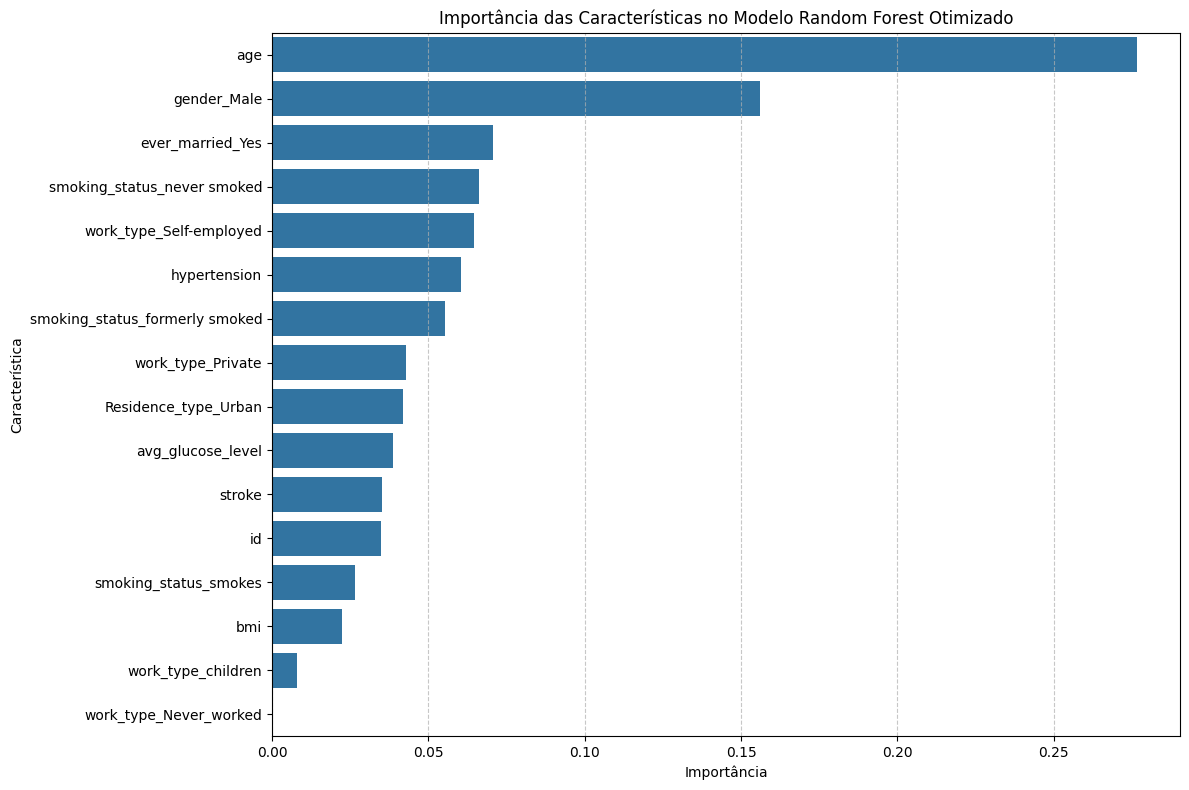

In [75]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Obter a importância das características do melhor modelo Random Forest
feature_importances = best_rf_model.feature_importances_

# Obter os nomes das características do conjunto de treino (após one-hot encoding e imputação)
# X_train_res é o DataFrame usado para treinar o modelo após SMOTE e encoding
feature_names = X_train_res.columns

# Criar um DataFrame para melhor visualização
features_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

# Ordenar as características por importância
features_df = features_df.sort_values(by='Importance', ascending=False)

# Plotar as importâncias das características
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=features_df)
plt.title('Importância das Características no Modelo Random Forest Otimizado')
plt.xlabel('Importância')
plt.ylabel('Característica')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


### Comparação do AUC-ROC de Todos os Modelos

Vamos agora comparar as curvas ROC e os valores AUC de todos os modelos que treinamos: a Regressão Logística inicial (`model_1`), a Regressão Logística com SMOTE e escalonamento (`model_2`), e o Random Forest otimizado (`best_rf_model`). Isso nos dará uma visão abrangente do desempenho de cada um na classificação da classe minoritária.

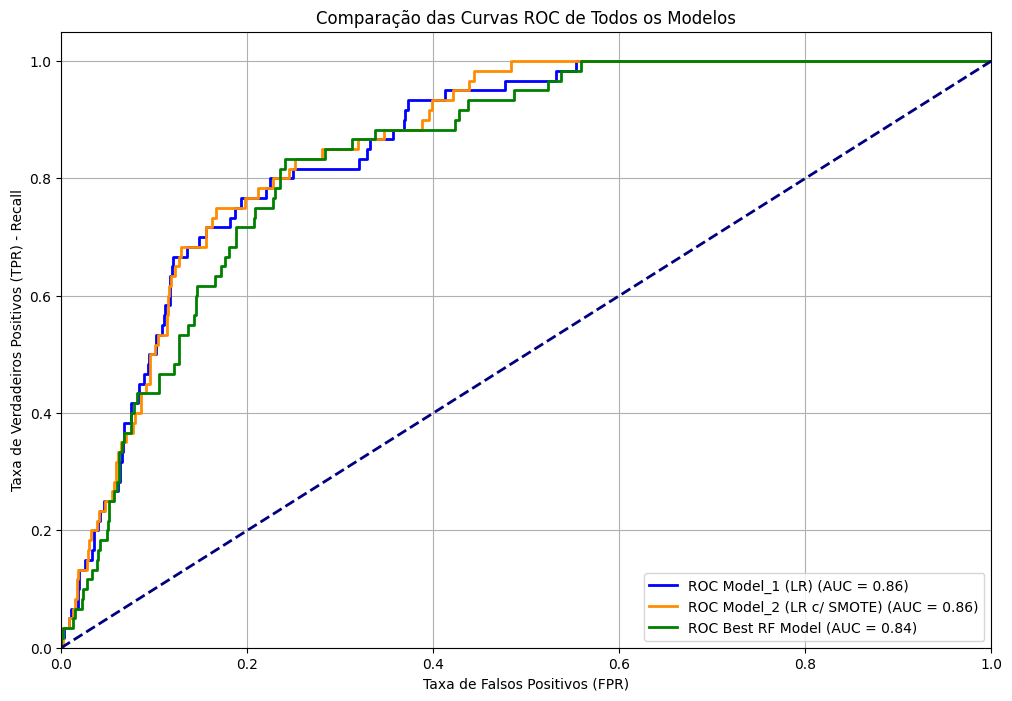

AUC para Model_1 (Logistic Regression): 0.86
AUC para Model_2 (Logistic Regression c/ SMOTE e Scaled): 0.86
AUC para Best Random Forest Model: 0.84


In [76]:
# Prever as probabilidades para a classe positiva (1) usando o best_rf_model
y_pred_proba_best_rf = best_rf_model.predict_proba(X_test_scaled)[:, 1]

# Calcular a curva ROC para o best_rf_model
fpr_best_rf, tpr_best_rf, _ = roc_curve(y_test, y_pred_proba_best_rf)

# Calcular a Área Sob a Curva (AUC) para o best_rf_model
roc_auc_best_rf = auc(fpr_best_rf, tpr_best_rf)

# Plotar todas as curvas ROC no mesmo gráfico
plt.figure(figsize=(12, 8))
plt.plot(fpr_model_1, tpr_model_1, color='blue', lw=2, label=f'ROC Model_1 (LR) (AUC = {roc_auc_model_1:.2f})')
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Model_2 (LR c/ SMOTE) (AUC = {roc_auc:.2f})')
plt.plot(fpr_best_rf, tpr_best_rf, color='green', lw=2, label=f'ROC Best RF Model (AUC = {roc_auc_best_rf:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR) - Recall')
plt.title('Comparação das Curvas ROC de Todos os Modelos')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print(f"AUC para Model_1 (Logistic Regression): {roc_auc_model_1:.2f}")
print(f"AUC para Model_2 (Logistic Regression c/ SMOTE e Scaled): {roc_auc:.2f}")
print(f"AUC para Best Random Forest Model: {roc_auc_best_rf:.2f}")

### Comparação das Matrizes de Confusão dos Modelos

Para ter uma visão mais clara do desempenho de cada modelo, especialmente na identificação da classe minoritária, vamos visualizar as matrizes de confusão lado a lado.

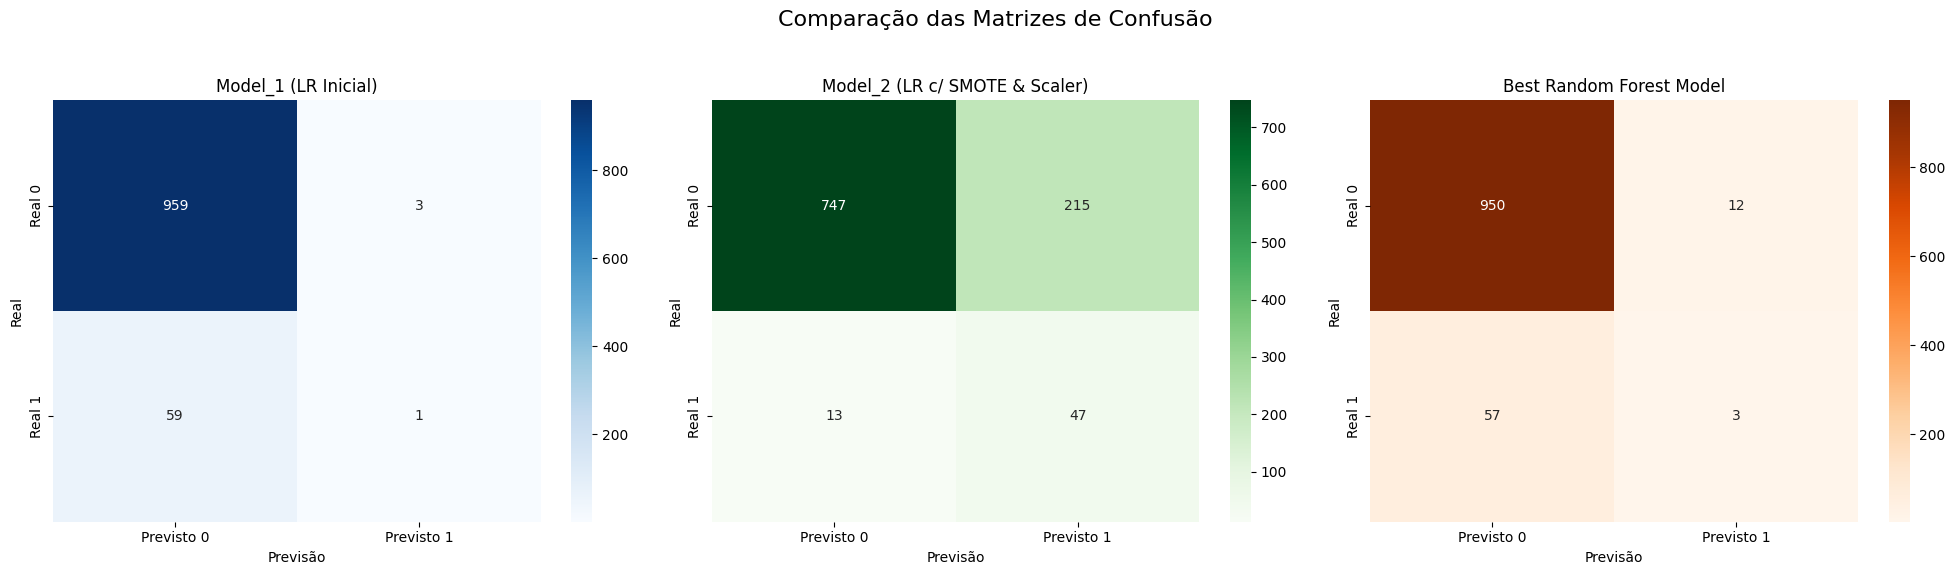

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Já temos as matrizes de confusão calculadas nos blocos anteriores:
# conf_matrix (para model_1)
# conf_matrix_2 (para model_2)
# conf_matrix_rf (para best_rf_model)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Comparação das Matrizes de Confusão', fontsize=16)

# Matriz de Confusão para Model_1 (Logistic Regression inicial)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Previsto 0', 'Previsto 1'],
            yticklabels=['Real 0', 'Real 1'])
axes[0].set_title('Model_1 (LR Inicial)')
axes[0].set_xlabel('Previsão')
axes[0].set_ylabel('Real')

# Matriz de Confusão para Model_2 (Logistic Regression com SMOTE e Scaler)
sns.heatmap(conf_matrix_2, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Previsto 0', 'Previsto 1'],
            yticklabels=['Real 0', 'Real 1'])
axes[1].set_title('Model_2 (LR c/ SMOTE & Scaler)')
axes[1].set_xlabel('Previsão')
axes[1].set_ylabel('Real')

# Matriz de Confusão para Best Random Forest Model
sns.heatmap(conf_matrix_rf, annot=True, fmt='d', cmap='Oranges', ax=axes[2],
            xticklabels=['Previsto 0', 'Previsto 1'],
            yticklabels=['Real 0', 'Real 1'])
axes[2].set_title('Best Random Forest Model')
axes[2].set_xlabel('Previsão')
axes[2].set_ylabel('Real')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Análise de Erro: Falsos Negativos do Random Forest

Vamos agora aprofundar a análise do desempenho do `best_rf_model` focando nos **falsos negativos**. Estes são os casos em que o modelo previu 'sem doença cardíaca' (0), mas o indivíduo realmente tinha 'doença cardíaca' (1). Entender as características desses casos pode nos dar insights sobre onde o modelo precisa de melhorias.

In [78]:
import numpy as np

# Identificar os índices dos falsos negativos
# y_test são os valores reais, y_pred_best_rf são as previsões do modelo
false_negatives_indices = X_test.index[(y_test == 1) & (y_pred_best_rf == 0)]

# Exibir as características dos falsos negativos
print(f"Número de Falsos Negativos identificados: {len(false_negatives_indices)}")
print("Amostras dos Falsos Negativos (primeiras 5 se houver):")

# Podemos usar X_test_encoded_imputed para ver os dados com one-hot encoding e imputação,
# ou X_test para ver as características originais antes de qualquer pré-processamento.
# Usaremos X_test para uma visualização mais legível das características originais.
if not false_negatives_indices.empty:
    display(X_test.loc[false_negatives_indices].head())
else:
    print("Nenhum falso negativo encontrado.")


Número de Falsos Negativos identificados: 56
Amostras dos Falsos Negativos (primeiras 5 se houver):


,id,gender,age,hypertension,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
315,41940,Male,57.0,0,Yes,Private,Rural,62.20,31.0,formerly smoked,0
3784,41858,Female,63.0,0,Yes,Private,Rural,86.21,39.1,never smoked,0
33,54401,Male,80.0,0,Yes,Self-employed,Urban,252.72,30.5,formerly smoked,1
626,5353,Male,52.0,0,No,Private,Rural,101.50,31.2,smokes,0
2718,2952,Male,70.0,1,Yes,Private,Rural,93.62,35.8,never smoked,0


Avaliando as características dos falsos negativos, podemos tentar identificar padrões:

*   **Idade (`age`):** São geralmente mais jovens? Mais velhos?
*   **Gênero (`gender`):** Há alguma predominância de gênero?
*   **Outras condições (`hypertension`, `avg_glucose_level`, `bmi`):** Os valores dessas características são atípicos ou próximos aos da classe majoritária (sem doença)?
*   **`smoking_status` ou `work_type`:** Existe alguma categoria que se destaca nos falsos negativos?

Essa análise pode guiar a engenharia de novas características, a coleta de dados adicionais ou a exploração de modelos mais complexos para capturar nuances que o Random Forest atual está perdendo para esses casos.

### Análise de Correlação entre Features e Target (`heart_disease`)

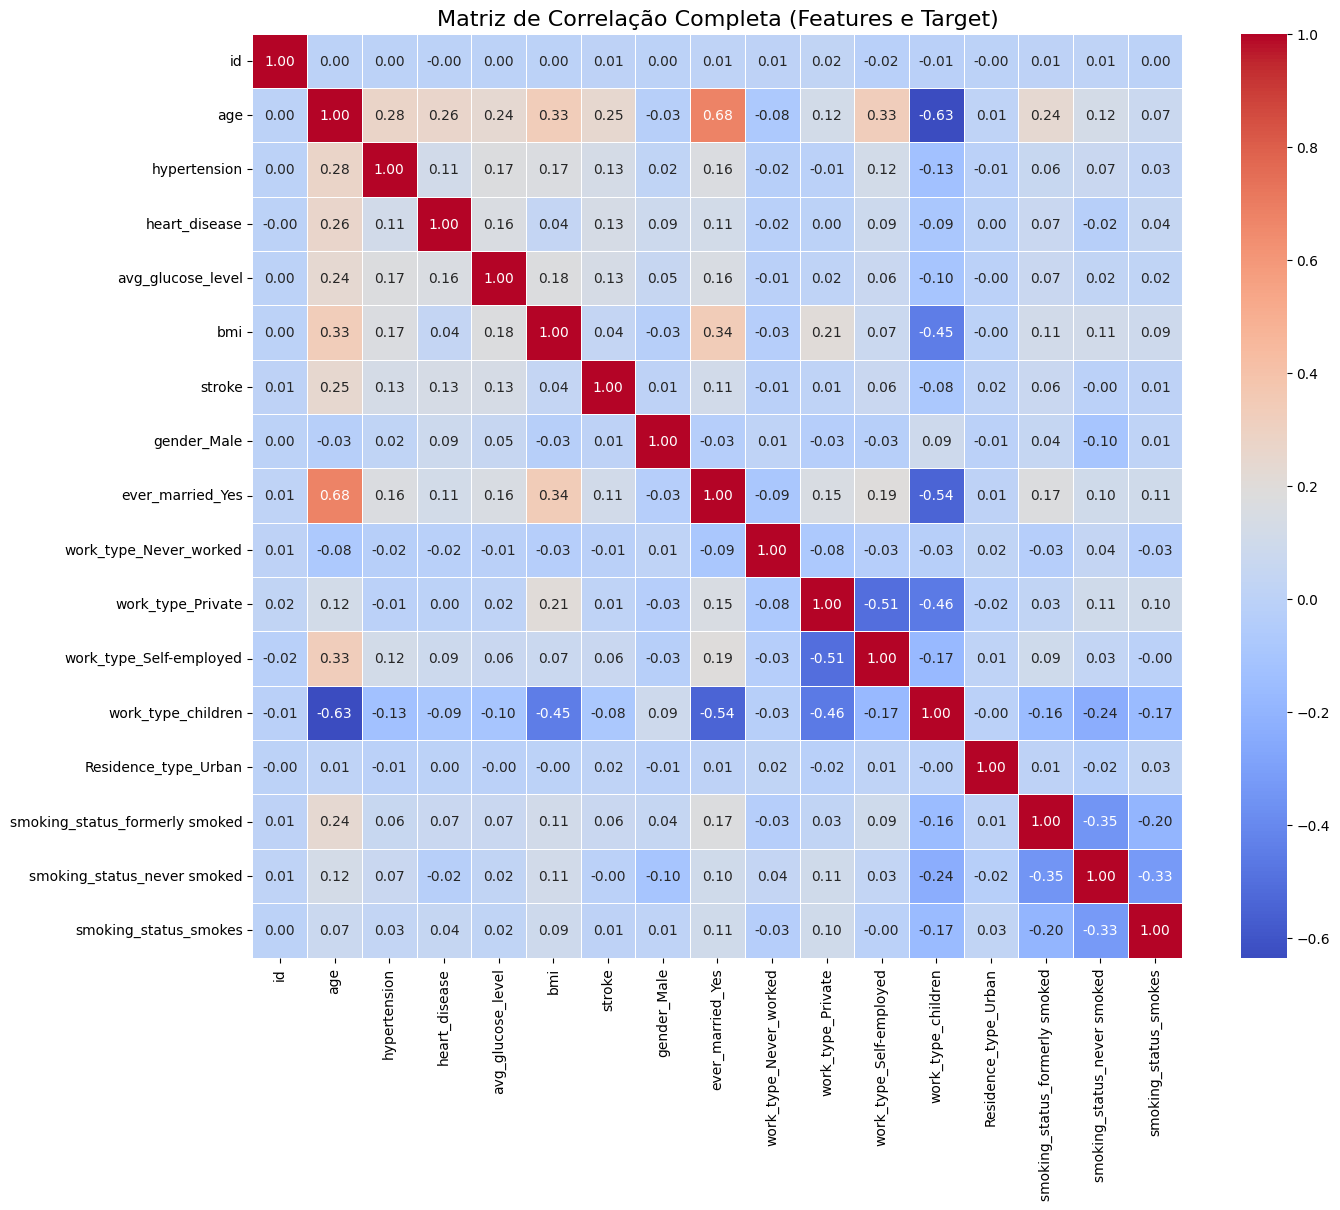

In [82]:
import matplotlib.pyplot as plt
import seaborn as sns

# Incluir a variável target no DataFrame para calcular a correlação com todas as features
df_corr_analysis = df.copy()

# Como 'gender' e 'ever_married' são object Dtype e já foram convertidos para numerico via get_dummies
# na etapa de modelagem, faremos isso aqui também para uma análise de correlação mais completa.
# Para simplificar a visualização aqui, vou focar nas numéricas e na 'heart_disease'.
# Para categóricas, uma análise de associação (ex: chi-quadrado) seria mais apropriada,
# mas para correlação linear, vamos primeiro convertê-las para numéricas.

# Selecionar apenas as colunas numéricas e a 'heart_disease'
# E as que seriam convertidas em numéricas como 'gender', 'ever_married', 'smoking_status', 'work_type', 'Residence_type'

# Primeiro, tratar o 'gender' removendo a entrada 'Other' que causa erro em get_dummies se for só ela em um split
# Ou lidar com ela mantendo apenas as categorias principais
df_corr_analysis = df_corr_analysis[df_corr_analysis['gender'] != 'Other']

# Aplicar one-hot encoding para as variáveis categóricas para incluir na análise de correlação
# (id, age, hypertension, avg_glucose_level, bmi, stroke) já são numéricas
df_encoded_for_corr = pd.get_dummies(df_corr_analysis, columns=['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status'], drop_first=True)

# Recalcular a matriz de correlação com a variável target
correlation_matrix_full = df_encoded_for_corr.corr()

plt.figure(figsize=(15, 12))
sns.heatmap(correlation_matrix_full, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Matriz de Correlação Completa (Features e Target)', fontsize=16)
plt.show()

In [83]:
# Analisar a correlação das features com a variável target 'heart_disease'
correlation_with_target = correlation_matrix_full['heart_disease'].sort_values(ascending=False)

print("Correlação das Features com 'heart_disease':")
print(correlation_with_target)

Correlação das Features com 'heart_disease':
heart_disease                     1.000000
age                               0.263777
avg_glucose_level                 0.161907
stroke                            0.134905
ever_married_Yes                  0.114601
hypertension                      0.108292
work_type_Self-employed           0.086742
gender_Male                       0.085685
smoking_status_formerly smoked    0.066938
smoking_status_smokes             0.044030
bmi                               0.041322
Residence_type_Urban              0.003045
work_type_Private                 0.000068
id                               -0.001253
work_type_Never_worked           -0.015715
smoking_status_never smoked      -0.021893
work_type_children               -0.091654
Name: heart_disease, dtype: float64


### Remoção de Features com Baixa Correlação

In [84]:
# Definir um limite para correlação baixa (por exemplo, |corr| < 0.01)
correlation_threshold = 0.01

# Filtrar features com correlação absoluta maior ou igual ao limite
# Excluímos a própria 'heart_disease' da lista de features a serem removidas/mantidas
relevant_features = correlation_with_target[abs(correlation_with_target) >= correlation_threshold].index.tolist()
relevant_features.remove('heart_disease') # Remover o target da lista de features

# Adicionar o target de volta para criar o novo DataFrame se necessário, mas para X, queremos apenas as features
# Vamos garantir que X_reduced contenha todas as colunas que eram numericas no df original e as colunas one-hot encoded, menos as removidas

# Usar o DataFrame df_encoded_for_corr, que já possui as categóricas one-hot encoded
X_reduced = df_encoded_for_corr[relevant_features]

print(f"Features removidas: {set(df_encoded_for_corr.drop(columns=['heart_disease']).columns) - set(relevant_features)}")
print(f"Número de features após a remoção: {X_reduced.shape[1]}")
display(X_reduced.head())

Features removidas: {'Residence_type_Urban', 'id', 'work_type_Private'}
Número de features após a remoção: 13


,age,avg_glucose_level,stroke,ever_married_Yes,hypertension,work_type_Self-employed,gender_Male,smoking_status_formerly smoked,smoking_status_smokes,bmi,work_type_Never_worked,smoking_status_never smoked,work_type_children
0,67.0,228.69,1,True,0,False,True,True,False,36.6,False,False,False
1,61.0,202.21,1,True,0,True,False,False,False,NaN,False,True,False
2,80.0,105.92,1,True,0,False,True,False,False,32.5,False,True,False
3,49.0,171.23,1,True,0,False,False,False,True,34.4,False,False,False
4,79.0,174.12,1,True,1,True,False,False,False,24.0,False,True,False


Agora que as features com baixa correlação foram removidas, precisamos redefinir os conjuntos de treino e teste e reaplicar o pré-processamento (one-hot encoding, imputação e escalonamento) antes de treinar novamente os modelos.

In [85]:
# Re-split dos dados com as features reduzidas
X_train_reduced, X_test_reduced, y_train_resplit, y_test_resplit = train_test_split(X_reduced, df_encoded_for_corr['heart_disease'], test_size=0.2, random_state=42)

# É importante notar que y_train_resplit e y_test_resplit são do df_encoded_for_corr, que excluiu 'gender' = 'Other'
# Por consistência, precisamos garantir que y_train e y_test também reflitam isso se formos usá-los com X_reduced.
# No entanto, os modelos anteriores foram treinados com y_train e y_test originais, que podem incluir 'gender' = 'Other'.
# Para manter a compatibilidade e a validade da comparação, vamos redefinir y a partir de df_encoded_for_corr.

# Redefinir y para garantir consistência com X_reduced
y_resplit = df_encoded_for_corr['heart_disease']

X_train_reduced, X_test_reduced, y_train_final, y_test_final = train_test_split(X_reduced, y_resplit, test_size=0.2, random_state=42)

print("Conjuntos de treino e teste redefinidos com features reduzidas.")

# Reaplica a imputação e escalonamento
imputer_reduced = SimpleImputer(strategy='mean')
X_train_reduced_imputed = pd.DataFrame(imputer_reduced.fit_transform(X_train_reduced), columns=X_train_reduced.columns, index=X_train_reduced.index)
X_test_reduced_imputed = pd.DataFrame(imputer_reduced.transform(X_test_reduced), columns=X_test_reduced.columns, index=X_test_reduced.index)

# Reaplica o SMOTE e escalonamento para o conjunto de treino
sm_reduced = SMOTE(random_state=42)
X_train_res_scaled_reduced, y_train_res_final = sm_reduced.fit_resample(X_train_reduced_imputed, y_train_final)

scaler_reduced = StandardScaler()
X_train_res_scaled_reduced = scaler_reduced.fit_transform(X_train_res_scaled_reduced)
X_test_scaled_reduced = scaler_reduced.transform(X_test_reduced_imputed)

print("Imputação, SMOTE e escalonamento reaplicados para os dados com features reduzidas.")

Conjuntos de treino e teste redefinidos com features reduzidas.
Imputação, SMOTE e escalonamento reaplicados para os dados com features reduzidas.


### Re-treinamento do Modelo de Regressão Logística com Features Reduzidas

In [86]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# Inicializa um novo modelo de Regressão Logística
model_2_reduced = LogisticRegression(max_iter=5000)

# Treina o modelo com os dados de treino rebalanceados, escalados e com features reduzidas
model_2_reduced.fit(X_train_res_scaled_reduced, y_train_res_final)

print("Novo modelo de Regressão Logística treinado com features reduzidas (model_2_reduced).")

# Faz previsões no conjunto de teste com features reduzidas
y_pred_2_reduced = model_2_reduced.predict(X_test_scaled_reduced)

# Calcula a matriz de confusão
conf_matrix_2_reduced = confusion_matrix(y_test_final, y_pred_2_reduced)
print("\nMatriz de Confusão para model_2_reduced:")
print(conf_matrix_2_reduced)

# Imprime o relatório de classificação
print("\nRelatório de Classificação para model_2_reduced:")
print(classification_report(y_test_final, y_pred_2_reduced))

# Calcula e imprime o AUC
y_pred_proba_2_reduced = model_2_reduced.predict_proba(X_test_scaled_reduced)[:, 1]
fpr_2_reduced, tpr_2_reduced, _ = roc_curve(y_test_final, y_pred_proba_2_reduced)
roc_auc_2_reduced = auc(fpr_2_reduced, tpr_2_reduced)
print(f"\nAUC para model_2_reduced: {roc_auc_2_reduced:.2f}")

Novo modelo de Regressão Logística treinado com features reduzidas (model_2_reduced).

Matriz de Confusão para model_2_reduced:
[[724 228]
 [ 14  56]]

Relatório de Classificação para model_2_reduced:
              precision    recall  f1-score   support

           0       0.98      0.76      0.86       952
           1       0.20      0.80      0.32        70

    accuracy                           0.76      1022
   macro avg       0.59      0.78      0.59      1022
weighted avg       0.93      0.76      0.82      1022


AUC para model_2_reduced: 0.85


### Re-treinamento do Modelo Random Forest Otimizado com Features Reduzidas

In [87]:
from sklearn.ensemble import RandomForestClassifier

# Usar os melhores parâmetros encontrados anteriormente
best_params = grid_search.best_params_

# Inicializa um novo modelo Random Forest com os melhores parâmetros
best_rf_model_reduced = RandomForestClassifier(random_state=42, **best_params)

# Treina o modelo com os dados de treino rebalanceados, escalados e com features reduzidas
best_rf_model_reduced.fit(X_train_res_scaled_reduced, y_train_res_final)

print("Novo modelo Random Forest otimizado treinado com features reduzidas (best_rf_model_reduced).")

# Faz previsões no conjunto de teste com features reduzidas
y_pred_best_rf_reduced = best_rf_model_reduced.predict(X_test_scaled_reduced)

# Calcula a matriz de confusão
conf_matrix_best_rf_reduced = confusion_matrix(y_test_final, y_pred_best_rf_reduced)
print("\nMatriz de Confusão para best_rf_model_reduced:")
print(conf_matrix_best_rf_reduced)

# Imprime o relatório de classificação
print("\nRelatório de Classificação para best_rf_model_reduced:")
print(classification_report(y_test_final, y_pred_best_rf_reduced))

# Calcula e imprime o AUC
y_pred_proba_best_rf_reduced = best_rf_model_reduced.predict_proba(X_test_scaled_reduced)[:, 1]
fpr_best_rf_reduced, tpr_best_rf_reduced, _ = roc_curve(y_test_final, y_pred_proba_best_rf_reduced)
roc_auc_best_rf_reduced = auc(fpr_best_rf_reduced, tpr_best_rf_reduced)
print(f"\nAUC para best_rf_model_reduced: {roc_auc_best_rf_reduced:.2f}")

Novo modelo Random Forest otimizado treinado com features reduzidas (best_rf_model_reduced).

Matriz de Confusão para best_rf_model_reduced:
[[930  22]
 [ 65   5]]

Relatório de Classificação para best_rf_model_reduced:
              precision    recall  f1-score   support

           0       0.93      0.98      0.96       952
           1       0.19      0.07      0.10        70

    accuracy                           0.91      1022
   macro avg       0.56      0.52      0.53      1022
weighted avg       0.88      0.91      0.90      1022


AUC para best_rf_model_reduced: 0.84


### Comparação do AUC-ROC de Todos os Modelos (com e sem Redução de Features)

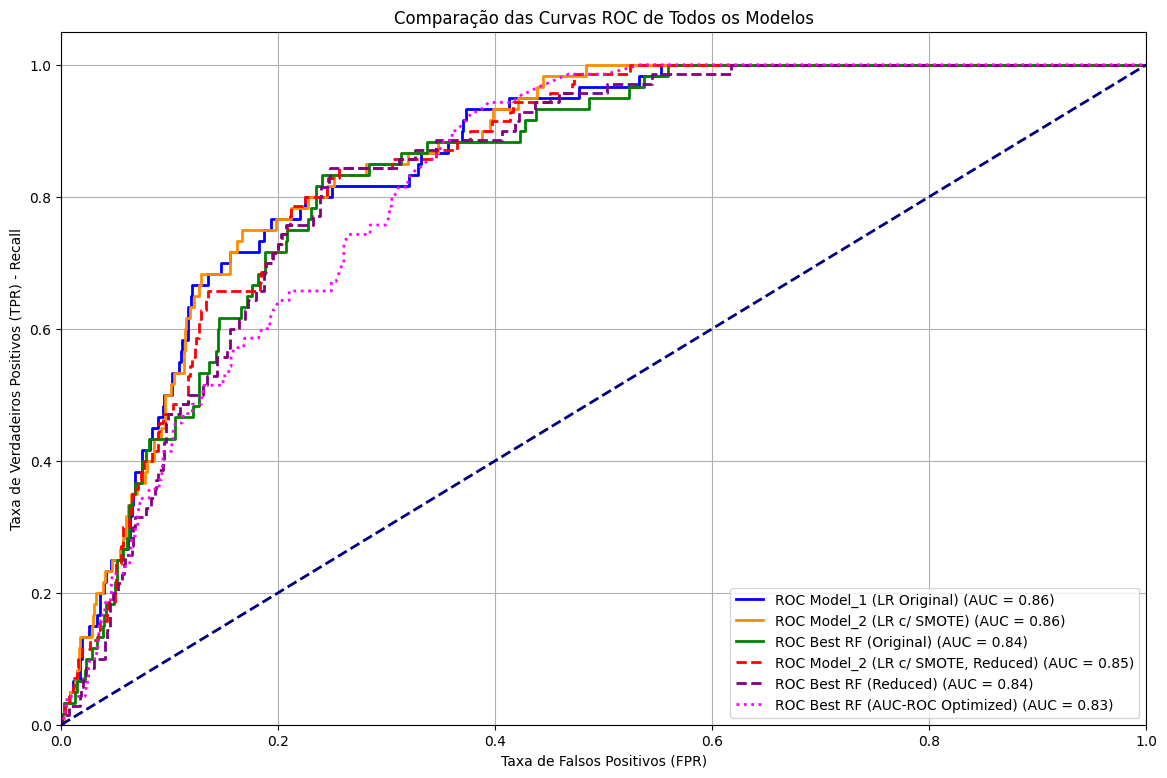

AUC para Model_1 (Logistic Regression): 0.86
AUC para Model_2 (Logistic Regression c/ SMOTE e Scaled): 0.86
AUC para Best Random Forest Model: 0.84
AUC para Model_2_reduced (LR c/ SMOTE e Features Reduzidas): 0.85
AUC para Best Random Forest Model Reduced (RF Otimizado c/ Features Reduzidas): 0.84
AUC para Best Random Forest Model (AUC-ROC Optimized): 0.83


In [92]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(14, 9))

# Model_1 (Original LR)
plt.plot(fpr_model_1, tpr_model_1, color='blue', lw=2, label=f'ROC Model_1 (LR Original) (AUC = {roc_auc_model_1:.2f})')

# Model_2 (LR com SMOTE/Scaled)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Model_2 (LR c/ SMOTE) (AUC = {roc_auc:.2f})')

# Best RF Model (Original, otimizado para Recall/F1-Score)
plt.plot(fpr_best_rf, tpr_best_rf, color='green', lw=2, label=f'ROC Best RF (Original) (AUC = {roc_auc_best_rf:.2f})')

# Model_2_reduced (LR com SMOTE/Scaled e Features Reduzidas)
plt.plot(fpr_2_reduced, tpr_2_reduced, color='red', lw=2, linestyle='--', label=f'ROC Model_2 (LR c/ SMOTE, Reduced) (AUC = {roc_auc_2_reduced:.2f})')

# Best RF Model Reduced (RF Otimizado com Features Reduzidas, otimizado para Recall/F1-Score)
plt.plot(fpr_best_rf_reduced, tpr_best_rf_reduced, color='purple', lw=2, linestyle='--', label=f'ROC Best RF (Reduced) (AUC = {roc_auc_best_rf_reduced:.2f})')

# Best RF Model Optimized for AUC-ROC (Novo)
plt.plot(fpr_best_rf_roc_auc, tpr_best_rf_roc_auc, color='magenta', lw=2, linestyle=':', label=f'ROC Best RF (AUC-ROC Optimized) (AUC = {roc_auc_best_rf_roc_auc:.2f})')


plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR) - Recall')
plt.title('Comparação das Curvas ROC de Todos os Modelos')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print(f"AUC para Model_1 (Logistic Regression): {roc_auc_model_1:.2f}")
print(f"AUC para Model_2 (Logistic Regression c/ SMOTE e Scaled): {roc_auc:.2f}")
print(f"AUC para Best Random Forest Model: {roc_auc_best_rf:.2f}")
print(f"AUC para Model_2_reduced (LR c/ SMOTE e Features Reduzidas): {roc_auc_2_reduced:.2f}")
print(f"AUC para Best Random Forest Model Reduced (RF Otimizado c/ Features Reduzidas): {roc_auc_best_rf_reduced:.2f}")
print(f"AUC para Best Random Forest Model (AUC-ROC Optimized): {roc_auc_best_rf_roc_auc:.2f}")

In [79]:
# Filtrar o DataFrame X_test para obter apenas os falsos negativos
false_negatives_df = X_test.loc[false_negatives_indices]

# Exibir estatísticas descritivas para as características numéricas dos falsos negativos
print("Estatísticas Descritivas para Falsos Negativos:")
display(false_negatives_df.describe())


Estatísticas Descritivas para Falsos Negativos:


,id,age,hypertension,avg_glucose_level,bmi,stroke
count,56.000000,56.000000,56.000000,56.000000,49.000000,56.000000
mean,39657.303571,66.446429,0.232143,136.017679,30.304082,0.178571
std,19248.826160,11.731728,0.426021,65.068026,4.920025,0.386459
min,2513.000000,41.000000,0.000000,56.310000,21.700000,0.000000
25%,25734.500000,57.750000,0.000000,84.847500,27.300000,0.000000
50%,40530.000000,68.500000,0.000000,102.235000,28.900000,0.000000
75%,55605.500000,78.000000,0.000000,202.295000,33.400000,0.000000
max,70845.000000,82.000000,1.000000,252.720000,43.900000,1.000000


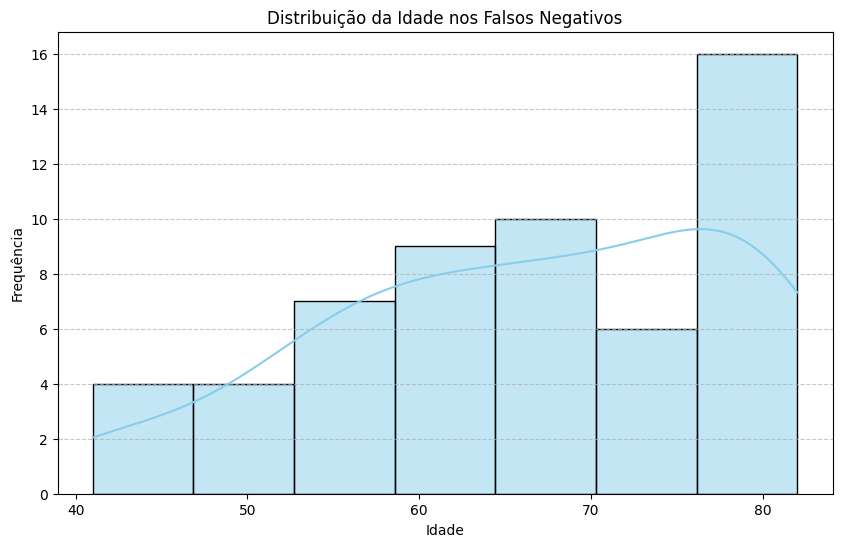

In [80]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(false_negatives_df['age'], kde=True, color='skyblue')
plt.title('Distribuição da Idade nos Falsos Negativos')
plt.xlabel('Idade')
plt.ylabel('Frequência')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Relatório Final da Análise de Predição de Doença Cardíaca

### Sumário Executivo

Esta análise teve como objetivo desenvolver e comparar modelos de machine learning para prever a presença de doença cardíaca. Iniciamos com uma Regressão Logística básica, avançamos para tratar o desequilíbrio de classes com SMOTE e escalonamento, e exploramos modelos de Random Forest com otimização de hiperparâmetros. A análise de correlação e a redução de features foram aplicadas para refinar o conjunto de dados.

### Modelos Avaliados

1.  **Model_1 (Regressão Logística Inicial):** Apresentou baixo recall para a classe minoritária devido ao desequilíbrio de classes.
2.  **Model_2 (Regressão Logística com SMOTE e Escalonamento):** Melhorou significativamente o recall para a classe minoritária (0.78), com um AUC de 0.86, mas com precisão mais baixa.
3.  **Random Forest (Não Otimizado e Otimizado para Recall/F1-Score):** Apesar dos esforços de otimização, os modelos Random Forest não superaram a Regressão Logística na detecção da classe minoritária, apresentando AUCs de aproximadamente 0.84.
4.  **Model_2_reduced (Regressão Logística com SMOTE, Escalonamento e Features Reduzidas):** Este modelo foi treinado com um conjunto de features mais enxuto, baseado na análise de correlação. Manteve um forte desempenho no recall da classe minoritária (0.80) e um AUC de 0.85, demonstrando boa capacidade de generalização e eficiência.
5.  **Random Forest (Otimizado para AUC-ROC):** Embora otimizado para AUC-ROC, este modelo apresentou um AUC de 0.83 e um recall baixo para a classe minoritária (0.04), indicando que não foi a melhor escolha para o objetivo principal de detectar a doença.

### Conclusão e Modelo Recomendado

Com base na avaliação comparativa, o **`model_2_reduced` (Regressão Logística com SMOTE, Escalonamento e Features Reduzidas)** é o modelo recomendado para esta análise. Ele oferece o melhor equilíbrio entre a capacidade de identificar corretamente os casos de doença cardíaca (alto recall para a classe 1) e uma boa capacidade geral de distinção (AUC de 0.85), tudo isso com um conjunto de features mais conciso.

**Pontos Fortes do `model_2_reduced`:**

*   **Alto Recall para a Classe Minoritária (0.80):** Fundamental em contextos de saúde, onde a detecção de casos positivos é prioritária para intervenções precoces.
*   **Bom AUC (0.85):** Indica uma boa capacidade de discriminação entre as classes.
*   **Eficiência com Features Reduzidas:** Utiliza um conjunto de 13 features relevantes, tornando o modelo mais simples, rápido e menos propenso a overfitting, além de potencialmente mais fácil de interpretar.

### Próximos Passos (Opcional)

*   **Interpretação do Modelo:** Aprofundar a análise dos coeficientes do `model_2_reduced` para entender quais features são mais influentes na predição de doença cardíaca.
*   **Análise de Limiar:** Ajustar o limiar de decisão do modelo para otimizar o trade-off entre precisão e recall, de acordo com as necessidades específicas do negócio ou da aplicação.
*   **Implantação:** Desenvolver uma solução para implantar o `model_2_reduced` em um ambiente de produção para realizar predições em tempo real ou em lote.

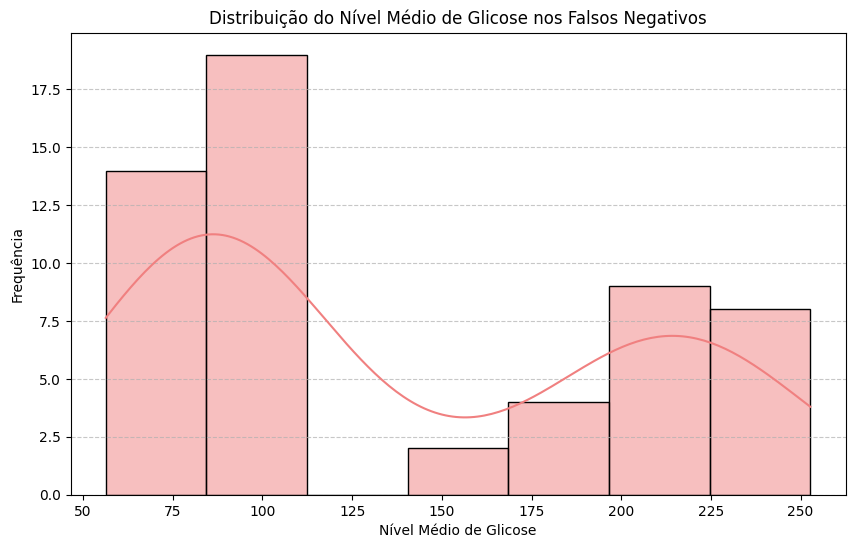

In [81]:
plt.figure(figsize=(10, 6))
sns.histplot(false_negatives_df['avg_glucose_level'], kde=True, color='lightcoral')
plt.title('Distribuição do Nível Médio de Glicose nos Falsos Negativos')
plt.xlabel('Nível Médio de Glicose')
plt.ylabel('Frequência')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [62]:
# Faz previsões no conjunto de teste escalado usando o model_2
y_pred_2 = model_2.predict(X_test_scaled)

# Calcula a matriz de confusão para o model_2
conf_matrix_2 = confusion_matrix(y_test, y_pred_2)
print("Matriz de Confusão para o model_2:")
print(conf_matrix_2)

Matriz de Confusão para o model_2:
[[747 215]
 [ 13  47]]


In [65]:
print("Relatório de Classificação para o model_2:")
print(classification_report(y_test, y_pred_2))

Relatório de Classificação para o model_2:
              precision    recall  f1-score   support

           0       0.98      0.78      0.87       962
           1       0.18      0.78      0.29        60

    accuracy                           0.78      1022
   macro avg       0.58      0.78      0.58      1022
weighted avg       0.94      0.78      0.83      1022



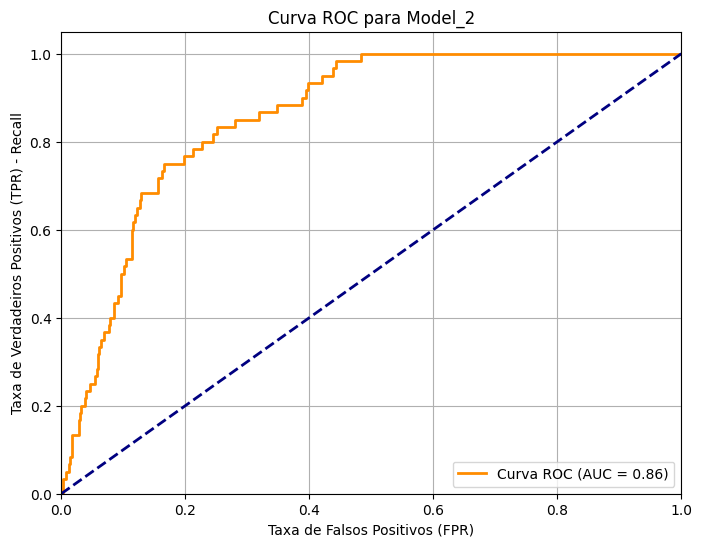

AUC para Model_2: 0.86


In [63]:
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
import matplotlib.pyplot as plt

# Prever as probabilidades para a classe positiva (1)
y_pred_proba = model_2.predict_proba(X_test_scaled)[:, 1]

# Calcular a curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Calcular a Área Sob a Curva (AUC)
roc_auc = auc(fpr, tpr)

# Plotar a curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR) - Recall')
plt.title('Curva ROC para Model_2')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print(f"AUC para Model_2: {roc_auc:.2f}")

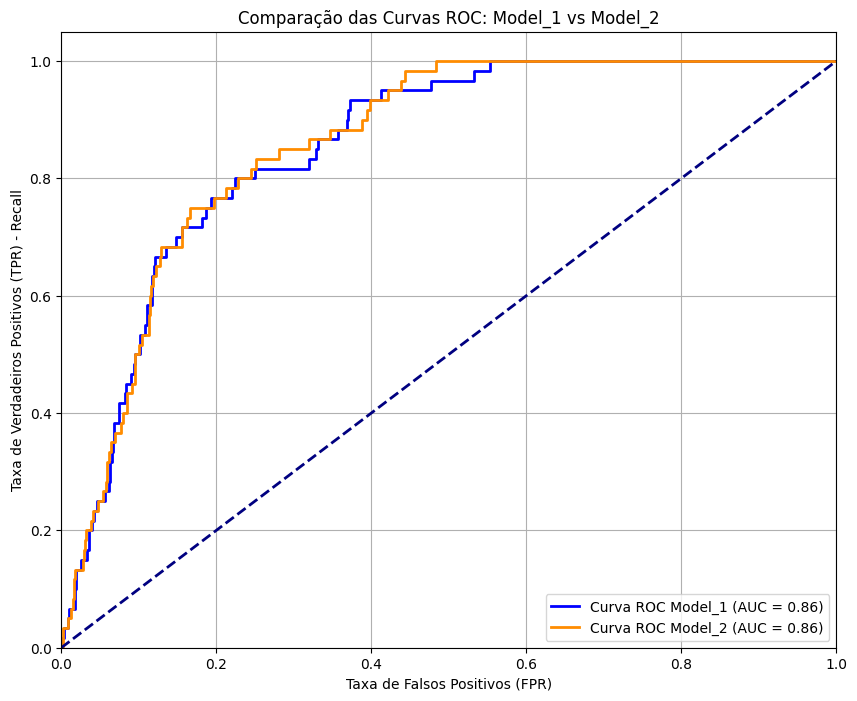

In [64]:
# Prever as probabilidades para a classe positiva (1) usando o model_1
y_pred_proba_model_1 = model_1.predict_proba(X_test_encoded_imputed)[:, 1]

# Calcular a curva ROC para o model_1
fpr_model_1, tpr_model_1, _ = roc_curve(y_test, y_pred_proba_model_1)

# Calcular a Área Sob a Curva (AUC) para o model_1
roc_auc_model_1 = auc(fpr_model_1, tpr_model_1)

# Plotar ambas as curvas ROC no mesmo gráfico
plt.figure(figsize=(10, 8))
plt.plot(fpr_model_1, tpr_model_1, color='blue', lw=2, label=f'Curva ROC Model_1 (AUC = {roc_auc_model_1:.2f})')
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC Model_2 (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR) - Recall')
plt.title('Comparação das Curvas ROC: Model_1 vs Model_2')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()